# 02 — Demo: 3D Bin Packing (un algoritmo)

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

**Instancia:** `showcase_3d_bpp_instance.json` — 30 piezas P1–P5 en 2 contenedores.

**Flujo:** 1) Presentar el problema → 2) `POST /algorithms/best_fit_decreasing_3d/execute` → 3) Ver la solución.

Entrada: `PackAlgorithmInput` (sin campo `algorithm`). Salida: `AlgorithmExecuteResponse`.

Usamos `best_fit_decreasing_3d` (ganador habitual en el benchmark de esta instancia).


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners
from _shared import viz_3d

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from _shared.loaders import load_showcase_instance, build_algorithm_execute_input
from packing_services.domain.models import Container

instance = load_showcase_instance('3D_BPP')
display.show_problem_overview(instance)


Contenedores disponibles:


ID,Largo,Ancho,Alto,Peso máx,Volumen
C1,100,80,80,500,640000
C2,100,80,80,500,640000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P1,50,40,30,6,6
P2,60,30,40,7,5
P3,45,45,25,5,4
P4,30,25,55,4,5
P5,20,20,20,2,10


Restricciones activas: non_overlap, containment, allow_rotation, max_weight


In [3]:
algo = 'best_fit_decreasing_3d'
payload = build_algorithm_execute_input(algo, problem_type='3D_BPP')
containers = [Container(**c) for c in payload['containers']]
print(f'--- Solución (POST /algorithms/{algo}/execute) ---')
result = runners.run_algorithm_execute(algo, payload)
solution = display.show_execute_result(result)


2026-09-10 18:43:01,696 | INFO    | packing_services.services.algorithm_execution_service | algorithm-execute name=best_fit_decreasing_3d problem_type=3D_BPP request_id=showcase-3d-bpp-001
2026-09-10 18:43:01,698 | INFO    | packing_services.services.packing_service | pack request_id=showcase-3d-bpp-001 algorithm=best_fit_decreasing_3d items=30 containers=2
2026-09-10 18:43:01,738 | INFO    | packing_services.services.packing_service | pack done request_id=showcase-3d-bpp-001 status=SolutionStatus.PARTIAL packed=27 unpacked=3 util=0.848


--- Solución (POST /algorithms/best_fit_decreasing_3d/execute) ---


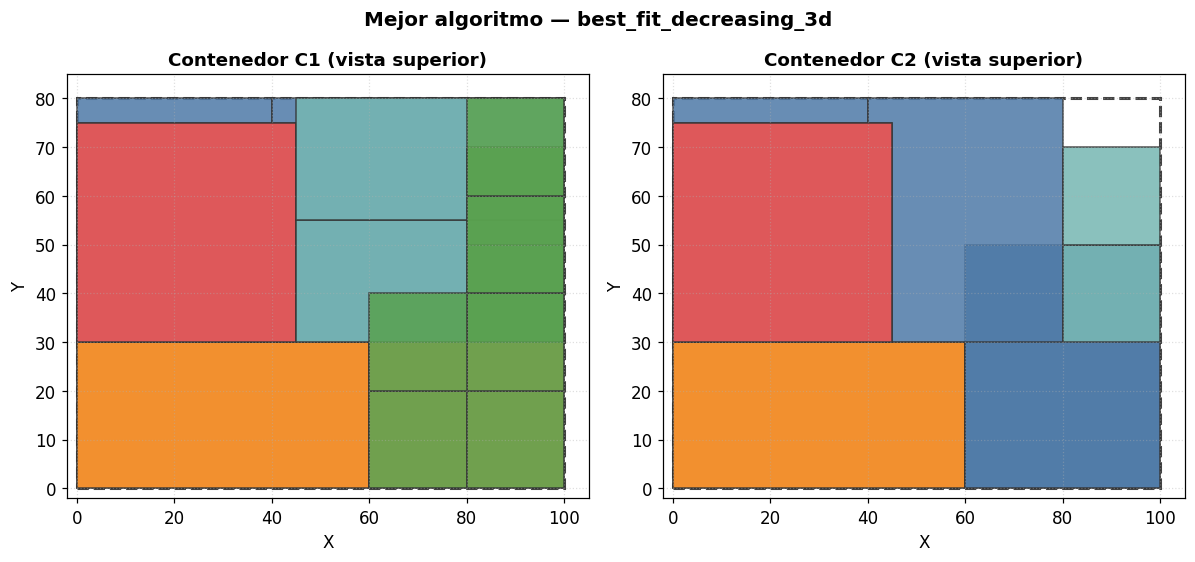

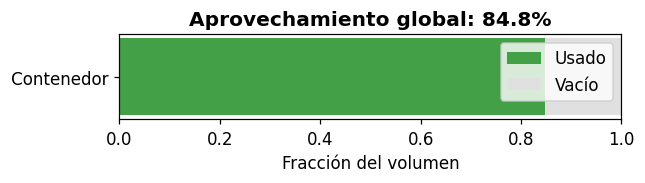

In [4]:
fig = viz.plot_all_container_views(solution, containers, title_prefix='Mejor algoritmo')
if fig: plt.show()
fig = viz.plot_utilization_bar(solution.metrics.volume_utilization, title='Aprovechamiento global')
plt.show()


In [5]:
# Vista 3D interactiva (Plotly Mesh3d, estilo D-Wave adaptado)
figs_3d = viz_3d.plot_solution_3d(solution, containers, title_prefix='3D')
for fig3d in figs_3d:
    fig3d.show()


Contenedores disponibles:


ID,Largo,Ancho,Alto,Peso máx,Volumen
C1,100,80,80,500,640000
C2,100,80,80,500,640000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P1,50,40,30,6,6
P2,60,30,40,7,5
P3,45,45,25,5,4
P4,30,25,55,4,5
P5,20,20,20,2,10


Restricciones activas: non_overlap, containment, allow_rotation, max_weight
Motores comparables — 3D Bin Packing:


#,Algoritmo,Nombre,Opcional
1,heuristic_3d_bpp_v1,Volume First Candidate Placement,No
2,first_fit_decreasing_3d,First Fit Decreasing 3D,No
3,extreme_points_3d,Extreme Points Heuristic,No
4,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
5,maximal_spaces_3d,Maximal Empty Spaces 3D,No
6,py3dbp_adapter,py3dbp Adapter (baseline externo),Sí


2026-09-10 18:43:03,458 | WARNING | packing_services.services.benchmark_service | benchmark engine=py3dbp_adapter error=[py3dbp_adapter] La librería 'py3dbp' no está instalada. Instálala con `pip install py3dbp` (o `pip install .[py3dbp]`) para habilitar este adaptador.


Nota: best_fit ~27 emp. (85% util) vs extreme_points ~22 (66%)
Benchmark — 3D Bin Packing


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Error
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0357,nan
2,first_fit_decreasing_3d,78.3%,25,5,Sí,0.0074,nan
3,heuristic_3d_bpp_v1,78.3%,25,5,Sí,0.0140,nan
4,maximal_spaces_3d,70.4%,23,7,Sí,0.0054,nan
5,extreme_points_3d,65.7%,22,8,Sí,0.0152,nan
6,py3dbp_adapter,0.0%,0,0,No,0.0000,[py3dbp_adapter] La librería 'py3dbp' no está instalada. Instálala con `pip inst


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


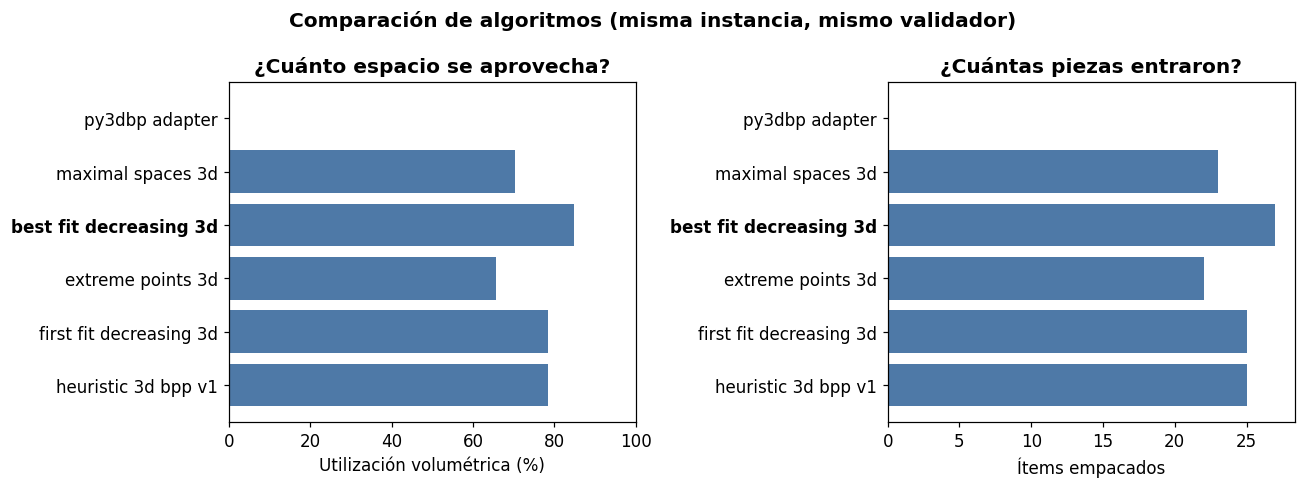

BenchmarkResponse(request_id='benchmark-3d-001', results=[BenchmarkEngineResult(engine='heuristic_3d_bpp_v1', status='partial', is_valid=True, metrics=Metrics(volume_utilization=0.783203, waste_volume=0.216797, containers_used=2, items_packed=25, items_unpacked=5, packed_volume=1002500.0, unpacked_volume=206250.0, total_item_volume=1208750.0, loaded_weight=111.0, execution_time_seconds=0.013982, constraint_violations=0), validation_report=ValidationReport(is_valid=True, violations=[]), solution=PackingSolution(request_id='benchmark-3d-001', status=<SolutionStatus.PARTIAL: 'partial'>, problem_type=<ProblemType.THREE_D_BPP: '3D_BPP'>, algorithm_name='heuristic_3d_bpp_v1', packed_items=[PackedItem(item_id='P2#1', container_id='C1', position=Point3D(x=0.0, y=0.0, z=0.0), orientation=Orientation(length=60.0, width=30.0, height=40.0), weight=7.0), PackedItem(item_id='P2#2', container_id='C1', position=Point3D(x=60.0, y=0.0, z=0.0), orientation=Orientation(length=30.0, width=60.0, height=40.0

In [6]:
from _shared.loaders import load_showcase_instance, problem_type_for_benchmark_group
group = '3D_BPP'
instance = load_showcase_instance(problem_type_for_benchmark_group(group))
display.show_problem_overview(instance)
display.run_and_show_showcase_benchmark(group, instance)


**Siguiente:** comparar en detalle → `03_comparacion_de_algoritmos.ipynb`
